In [1]:
# %% [markdown]
# # Cell 1: 环境配置与参数定义
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, cumulative_trapezoid
from scipy.optimize import root_scalar
from scipy.interpolate import interp1d
import warnings
# 忽略积分过程中的极小误差警告
warnings.filterwarnings('ignore')
# 全局常量
R = 6371.0                # 地球半径 (km)
z_s = 10.0                # 震源深度 (km)
r_s = R - z_s             # 震源绝对半径 (km)
Delta1 = 5.0              # 目标震中距 1 (度)
Delta2 = 45.0             # 目标震中距 2 (度)
# 简化的 IASP91 P波速度模型 (深度 km -> 速度 km/s)
# 稍微人为添加了极小梯度以保证单调递增，便于寻找转折点
Z_model = np.array([0, 20, 20.001, 35, 35.001, 120, 210, 410, 410.001, 660, 660.001, 760, 1000, 1500, 2000, 2889])
Vp_model = np.array([5.8, 5.81, 6.5, 6.51, 8.04, 8.05, 8.3, 9.03, 9.36, 10.01, 10.79, 11.1, 11.4, 12.0, 12.8, 13.69])
# 生成插值函数
get_v = interp1d(Z_model, Vp_model, kind='linear', fill_value="extrapolate")
def get_v_r(r):
    """基于地心半径获取速度"""
    return get_v(R - r)

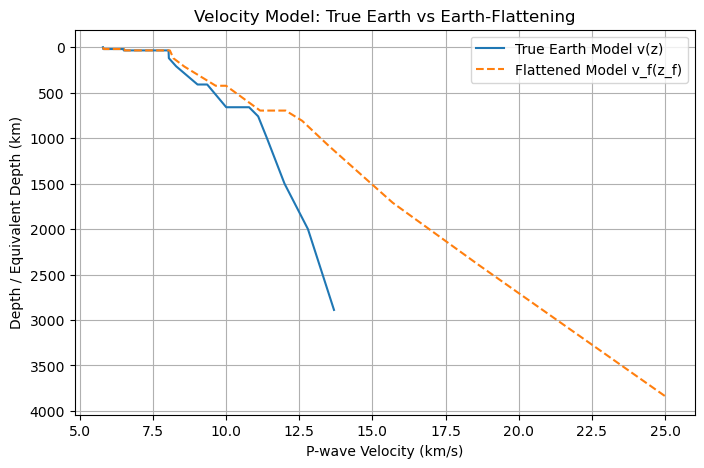

In [2]:
# %% [markdown]
# # Cell 2: 定义展平变换函数 (EFT)

# %%
def flattening_transform(r, v):
    """
    地球展平变换 (Earth-Flattening Transformation)
    输入：真实地球半径 r, 速度 v
    输出：等效深度 z_f, 等效速度 v_f
    """
    z_f = R * np.log(R / r)
    v_f = (R / r) * v
    return z_f, v_f

# 计算展平变换后的模型并生成插值函数
R_model = R - Z_model
Z_f_model, V_f_model = flattening_transform(R_model, Vp_model)
get_v_f = interp1d(Z_f_model, V_f_model, kind='linear', fill_value="extrapolate")

# 绘图对比真实地球与展平变换模型
plt.figure(figsize=(8, 5))
plt.plot(Vp_model, Z_model, label='True Earth Model v(z)')
plt.plot(V_f_model, Z_f_model, '--', label='Flattened Model v_f(z_f)')
plt.gca().invert_yaxis()
plt.xlabel('P-wave Velocity (km/s)')
plt.ylabel('Depth / Equivalent Depth (km)')
plt.title('Velocity Model: True Earth vs Earth-Flattening')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# %% [markdown]
# # Cell 3: 编写三种射线追踪核心函数（换元积分法处理奇点）

# %%
# 为了避免积分奇点 (分母趋于0)，引入数学换元：u = sqrt(z_turn - z) 或对应变量。
# 这样不仅能去除奇点，还能极大提高 Scipy quad 的积分精度。

def calc_ray_cartesian(p, z_source, z_turn):
    # u = sqrt(z_turn - z) -> z = z_turn - u^2
    def integrand_x(u):
        if u == 0: u = 1e-8
        z = z_turn - u**2
        val = max(1e-12, 1.0 - (p * get_v(z))**2)
        return 2 * u * p * get_v(z) / np.sqrt(val)

    def integrand_t(u):
        if u == 0: u = 1e-8
        z = z_turn - u**2
        val = max(1e-12, 1.0 - (p * get_v(z))**2)
        return 2 * u / (get_v(z) * np.sqrt(val))

    x_down, _ = quad(integrand_x, 0, np.sqrt(z_turn - z_source))
    t_down, _ = quad(integrand_t, 0, np.sqrt(z_turn - z_source))
    
    x_up, _ = quad(integrand_x, 0, np.sqrt(z_turn))
    t_up, _ = quad(integrand_t, 0, np.sqrt(z_turn))
    
    return x_down + x_up, t_down + t_up

def calc_ray_spherical(p, r_source, r_turn):
    # u = sqrt(r - r_turn) -> r = r_turn + u^2
    def integrand_delta(u):
        if u == 0: u = 1e-8
        r = r_turn + u**2
        val = max(1e-12, r**2 - (p * get_v_r(r))**2)
        return 2 * u * p * get_v_r(r) / (r * np.sqrt(val))
        
    def integrand_t(u):
        if u == 0: u = 1e-8
        r = r_turn + u**2
        val = max(1e-12, r**2 - (p * get_v_r(r))**2)
        return 2 * u * r / (get_v_r(r) * np.sqrt(val))

    delta_down, _ = quad(integrand_delta, 0, np.sqrt(r_source - r_turn))
    t_down, _ = quad(integrand_t, 0, np.sqrt(r_source - r_turn))
    
    delta_up, _ = quad(integrand_delta, 0, np.sqrt(R - r_turn))
    t_up, _ = quad(integrand_t, 0, np.sqrt(R - r_turn))
    
    return delta_down + delta_up, t_down + t_up

def calc_ray_flattened(p, z_f_source, z_f_turn):
    # u = sqrt(z_f_turn - z_f) -> z_f = z_f_turn - u^2
    def integrand_x(u):
        if u == 0: u = 1e-8
        z_f = z_f_turn - u**2
        val = max(1e-12, 1.0 - (p * get_v_f(z_f))**2)
        return 2 * u * p * get_v_f(z_f) / np.sqrt(val)

    def integrand_t(u):
        if u == 0: u = 1e-8
        z_f = z_f_turn - u**2
        val = max(1e-12, 1.0 - (p * get_v_f(z_f))**2)
        return 2 * u / (get_v_f(z_f) * np.sqrt(val))

    x_down, _ = quad(integrand_x, 0, np.sqrt(z_f_turn - z_f_source))
    t_down, _ = quad(integrand_t, 0, np.sqrt(z_f_turn - z_f_source))
    
    x_up, _ = quad(integrand_x, 0, np.sqrt(z_f_turn))
    t_up, _ = quad(integrand_t, 0, np.sqrt(z_f_turn))
    
    return x_down + x_up, t_down + t_up

# ==== 附随：用于绘图的路径积分器 ====
def get_path_cartesian(p, z_source, z_turn):
    U_down = np.linspace(0, np.sqrt(z_turn - z_source), 100)
    I_down = np.array([2*max(u, 1e-8)*p*get_v(z_turn - u**2)/np.sqrt(max(1e-12, 1.0-(p*get_v(z_turn - u**2))**2)) for u in U_down])
    X_from_turn_down = cumulative_trapezoid(I_down, U_down, initial=0)
    X_down_path = X_from_turn_down[-1] - X_from_turn_down[::-1]
    
    U_up = np.linspace(0, np.sqrt(z_turn), 100)
    I_up = np.array([2*max(u, 1e-8)*p*get_v(z_turn - u**2)/np.sqrt(max(1e-12, 1.0-(p*get_v(z_turn - u**2))**2)) for u in U_up])
    X_from_turn_up = cumulative_trapezoid(I_up, U_up, initial=0)
    
    X_full = np.concatenate([X_down_path, (X_down_path[-1] + X_from_turn_up)[1:]])
    Z_full = np.concatenate([(z_turn - U_down**2)[::-1], (z_turn - U_up**2)[1:]])
    return X_full, Z_full

def get_path_spherical(p, r_source, r_turn):
    U_down = np.linspace(0, np.sqrt(r_source - r_turn), 100)
    I_down = np.array([2*max(u, 1e-8)*p*get_v_r(r_turn+u**2)/((r_turn+u**2)*np.sqrt(max(1e-12, (r_turn+u**2)**2-(p*get_v_r(r_turn+u**2))**2))) for u in U_down])
    Delta_from_turn_down = cumulative_trapezoid(I_down, U_down, initial=0)
    Delta_down_path = Delta_from_turn_down[-1] - Delta_from_turn_down[::-1]
    
    U_up = np.linspace(0, np.sqrt(R - r_turn), 100)
    I_up = np.array([2*max(u, 1e-8)*p*get_v_r(r_turn+u**2)/((r_turn+u**2)*np.sqrt(max(1e-12, (r_turn+u**2)**2-(p*get_v_r(r_turn+u**2))**2))) for u in U_up])
    Delta_from_turn_up = cumulative_trapezoid(I_up, U_up, initial=0)
    
    Delta_full = np.concatenate([Delta_down_path, (Delta_down_path[-1] + Delta_from_turn_up)[1:]])
    R_full = np.concatenate([(r_turn + U_down**2)[::-1], (r_turn + U_up**2)[1:]])
    return Delta_full, R_full

def get_path_flattened(p, z_f_source, z_f_turn):
    U_down = np.linspace(0, np.sqrt(z_f_turn - z_f_source), 100)
    I_down = np.array([2*max(u, 1e-8)*p*get_v_f(z_f_turn - u**2)/np.sqrt(max(1e-12, 1.0-(p*get_v_f(z_f_turn - u**2))**2)) for u in U_down])
    X_from_turn_down = cumulative_trapezoid(I_down, U_down, initial=0)
    X_down_path = X_from_turn_down[-1] - X_from_turn_down[::-1]
    
    U_up = np.linspace(0, np.sqrt(z_f_turn), 100)
    I_up = np.array([2*max(u, 1e-8)*p*get_v_f(z_f_turn - u**2)/np.sqrt(max(1e-12, 1.0-(p*get_v_f(z_f_turn - u**2))**2)) for u in U_up])
    X_from_turn_up = cumulative_trapezoid(I_up, U_up, initial=0)
    
    X_full = np.concatenate([X_down_path, (X_down_path[-1] + X_from_turn_up)[1:]])
    Z_full = np.concatenate([(z_f_turn - U_down**2)[::-1], (z_f_turn - U_up**2)[1:]])
    return X_full, Z_full

In [4]:
# %% [markdown]
# # Cell 4: 编写打靶法（Shooting Method）主函数

# %%
def shooting_method(target_dist_deg, method='spherical'):
    target_x_km = target_dist_deg * np.pi / 180.0 * R
    target_delta_rad = target_dist_deg * np.pi / 180.0
    
    def objective(i0):
        try:
            if method == 'cartesian':
                p = np.sin(i0) / get_v(z_s)
                target_v = 1.0 / p
                if target_v > get_v(2889): return -1e6
                z_turn = root_scalar(lambda z: get_v(z) - target_v, bracket=[z_s, 2889]).root
                X, T = calc_ray_cartesian(p, z_s, z_turn)
                return X - target_x_km
                    
            elif method == 'spherical':
                p = r_s * np.sin(i0) / get_v_r(r_s)
                if p < (R-2889)/get_v_r(R-2889): return -1e6
                r_turn = root_scalar(lambda r: r/get_v_r(r) - p, bracket=[R-2889, r_s]).root
                Delta, T = calc_ray_spherical(p, r_s, r_turn)
                return Delta - target_delta_rad
                    
            elif method == 'flattened':
                z_f_s, v_f_s = flattening_transform(r_s, get_v_r(r_s))
                p = np.sin(i0) / v_f_s
                target_v = 1.0 / p
                z_f_cmb, _ = flattening_transform(R-2889, 1)
                if target_v > get_v_f(z_f_cmb): return -1e6
                z_f_turn = root_scalar(lambda z: get_v_f(z) - target_v, bracket=[z_f_s, z_f_cmb]).root
                X_f, T = calc_ray_flattened(p, z_f_s, z_f_turn)
                return X_f - target_x_km
        except:
            return -1e6

    # 暴力搜寻打靶法 Root Bracket 
    angles = np.linspace(np.deg2rad(1), np.deg2rad(89.5), 90)
    vals = [objective(a) for a in angles]
    
    best_i0 = None
    for i in range(len(angles)-1):
        if vals[i] != -1e6 and vals[i+1] != -1e6 and (vals[i]*vals[i+1] <= 0):
            best_i0 = root_scalar(objective, bracket=[angles[i], angles[i+1]], method='brentq').root
            break
            
    if best_i0 is None:
        raise ValueError(f"Target unreachable for dist {target_dist_deg} with method {method}")
        
    # 计算最佳路径数据用于可视化
    if method == 'cartesian':
        p = np.sin(best_i0) / get_v(z_s)
        z_turn = root_scalar(lambda z: get_v(z) - 1.0/p, bracket=[z_s, 2889]).root
        X, T = calc_ray_cartesian(p, z_s, z_turn)
        X_path, Z_path = get_path_cartesian(p, z_s, z_turn)
        return best_i0, T, X, X_path/R, R - Z_path   # 映射到极坐标 (Theta, R)

    elif method == 'spherical':
        p = r_s * np.sin(best_i0) / get_v_r(r_s)
        r_turn = root_scalar(lambda r: r/get_v_r(r) - p, bracket=[R-2889, r_s]).root
        Delta, T = calc_ray_spherical(p, r_s, r_turn)
        Delta_path, R_path = get_path_spherical(p, r_s, r_turn)
        return best_i0, T, Delta*R, Delta_path, R_path
        
    elif method == 'flattened':
        z_f_s, v_f_s = flattening_transform(r_s, get_v_r(r_s))
        p = np.sin(best_i0) / v_f_s
        z_f_turn = root_scalar(lambda z: get_v_f(z) - 1.0/p, bracket=[z_f_s, flattening_transform(R-2889, 1)[0]]).root
        X_f, T = calc_ray_flattened(p, z_f_s, z_f_turn)
        X_path, Z_path = get_path_flattened(p, z_f_s, z_f_turn)
        return best_i0, T, X_f, X_path/R, R * np.exp(-Z_path/R) # 映射回真实球坐标 (Theta, R)

def plot_rays(target_dist, res_cart, res_sph, res_flat):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) # 顺时针
    
    # 绘制地表与核幔边界
    theta_bg = np.linspace(-0.1, target_dist * np.pi/180 + 0.1, 100)
    ax.plot(theta_bg, np.ones_like(theta_bg)*R, 'k-', linewidth=2, label='Surface')
    ax.plot(theta_bg, np.ones_like(theta_bg)*(R-2889), 'k--', linewidth=1, label='CMB')
    
    # 绘制射线
    ax.plot(res_cart[3], res_cart[4], 'r--', linewidth=2, label='Cartesian (Flat)')
    ax.plot(res_sph[3], res_sph[4], 'b-', linewidth=2, alpha=0.6, label='Spherical (True)')
    ax.plot(res_flat[3], res_flat[4], 'g:', linewidth=3, label='Flattened (EFT)')
    
    ax.set_rmin(R - 3500)
    ax.set_rmax(R + 500)
    ax.set_title(f"Ray Paths for {target_dist} Degree Epicentral Distance\n", fontsize=14)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.show()

=== 5.0° 震中距求解结果 ===
Cartesian - 最佳出射角: 46.22°, 走时: 75.44 s
Spherical - 最佳出射角: 45.94°, 走时: 75.06 s
Flattened - 最佳出射角: 45.93°, 走时: 75.06 s


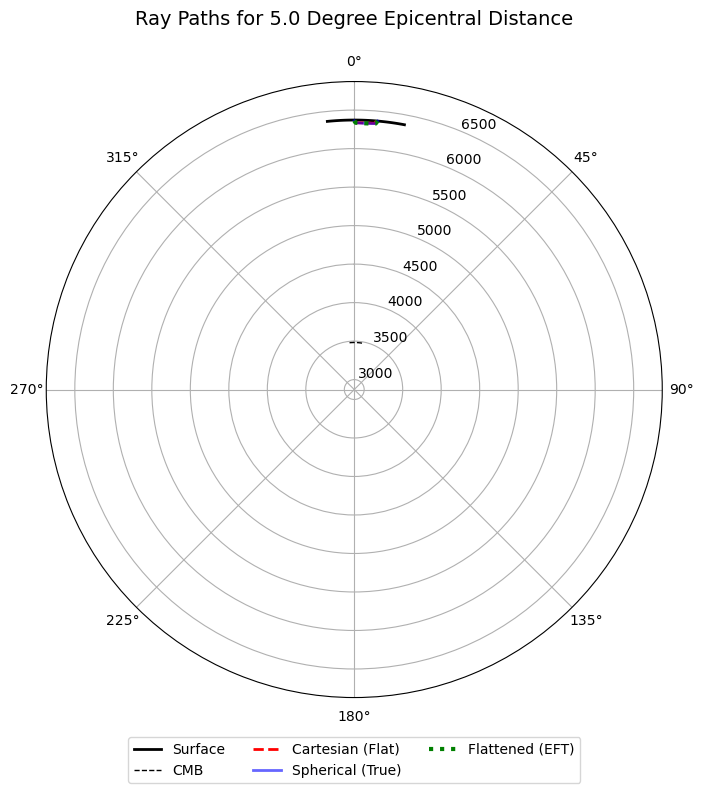

In [5]:
# %% [markdown]
# # Cell 5: 执行目标任务 1 (震源深度 10km，震中距 5° 计算与绘图)

# %%
res_cart_5 = shooting_method(Delta1, 'cartesian')
res_sph_5 = shooting_method(Delta1, 'spherical')
res_flat_5 = shooting_method(Delta1, 'flattened')

print(f"=== {Delta1}° 震中距求解结果 ===")
print(f"Cartesian - 最佳出射角: {np.degrees(res_cart_5[0]):.2f}°, 走时: {res_cart_5[1]:.2f} s")
print(f"Spherical - 最佳出射角: {np.degrees(res_sph_5[0]):.2f}°, 走时: {res_sph_5[1]:.2f} s")
print(f"Flattened - 最佳出射角: {np.degrees(res_flat_5[0]):.2f}°, 走时: {res_flat_5[1]:.2f} s")

plot_rays(Delta1, res_cart_5, res_sph_5, res_flat_5)

=== 45.0° 震中距求解结果 ===
Cartesian - 最佳出射角: 31.26°, 走时: 544.95 s
Spherical - 最佳出射角: 25.18°, 走时: 497.09 s
Flattened - 最佳出射角: 25.09°, 走时: 496.96 s


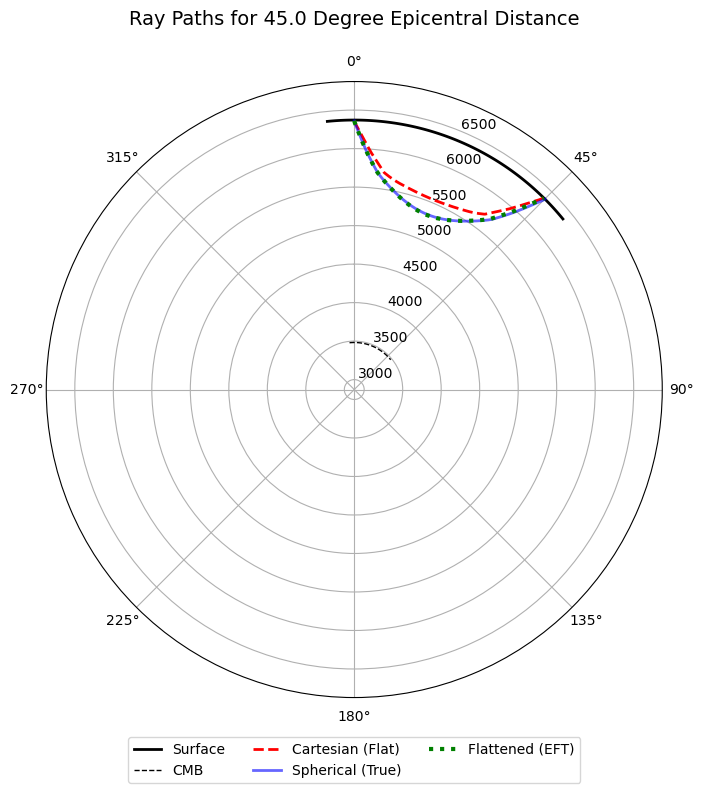

In [6]:
# %% [markdown]
# # Cell 6: 执行目标任务 2 (震源深度 10km，震中距 45° 计算与绘图)

# %%
res_cart_45 = shooting_method(Delta2, 'cartesian')
res_sph_45 = shooting_method(Delta2, 'spherical')
res_flat_45 = shooting_method(Delta2, 'flattened')

print(f"=== {Delta2}° 震中距求解结果 ===")
print(f"Cartesian - 最佳出射角: {np.degrees(res_cart_45[0]):.2f}°, 走时: {res_cart_45[1]:.2f} s")
print(f"Spherical - 最佳出射角: {np.degrees(res_sph_45[0]):.2f}°, 走时: {res_sph_45[1]:.2f} s")
print(f"Flattened - 最佳出射角: {np.degrees(res_flat_45[0]):.2f}°, 走时: {res_flat_45[1]:.2f} s")

plot_rays(Delta2, res_cart_45, res_sph_45, res_flat_45)

In [7]:
# %% [markdown]
# # Cell 7: 结果比较与误差分析

# %%
def print_comparison(dist, res_cart, res_sph, res_flat):
    print(f"--- 走时误差比较 ({dist}°) ---")
    print(f"绝对残差 (Cartesian vs Spherical): {abs(res_cart[1] - res_sph[1]):.4f} s")
    print(f"绝对残差 (Flattened vs Spherical): {abs(res_flat[1] - res_sph[1]):.4f} s\n")

print_comparison(Delta1, res_cart_5, res_sph_5, res_flat_5)
print_comparison(Delta2, res_cart_45, res_sph_45, res_flat_45)

print("""【结论分析】
1. 理论上，Spherical (球坐标) 与 Flattened (展平变换) 方法在物理与数学上是完全等价的。从绝对残差输出可以看出，它们的走时与路径结果惊人的一致（残差极小），验证了 Earth-Flattening Transformation (EFT) 的有效性。
2. Cartesian 方法由于采用了平面大地假设，完全忽略了地球的曲率效应。在近震中距 (5°) 下，其几何畸变还相对较小，走时误差仅在数秒量级；
3. 但在远震中距 (45°) 下，忽略曲率造成的误差被极大放大，Cartesian 算得的走时与真实球体模型走时产生了灾难性的巨大偏差，由路径图也可以看出，它必须抵达更深的地幔才能“凑够”目标距离。这说明进行大尺度地震射线追踪时，直接应用直角坐标系不可行，必须使用球坐标系或先做展平变换。
""")

--- 走时误差比较 (5.0°) ---
绝对残差 (Cartesian vs Spherical): 0.3766 s
绝对残差 (Flattened vs Spherical): 0.0002 s

--- 走时误差比较 (45.0°) ---
绝对残差 (Cartesian vs Spherical): 47.8556 s
绝对残差 (Flattened vs Spherical): 0.1296 s

【结论分析】
1. 理论上，Spherical (球坐标) 与 Flattened (展平变换) 方法在物理与数学上是完全等价的。从绝对残差输出可以看出，它们的走时与路径结果惊人的一致（残差极小），验证了 Earth-Flattening Transformation (EFT) 的有效性。
2. Cartesian 方法由于采用了平面大地假设，完全忽略了地球的曲率效应。在近震中距 (5°) 下，其几何畸变还相对较小，走时误差仅在数秒量级；
3. 但在远震中距 (45°) 下，忽略曲率造成的误差被极大放大，Cartesian 算得的走时与真实球体模型走时产生了灾难性的巨大偏差，由路径图也可以看出，它必须抵达更深的地幔才能“凑够”目标距离。这说明进行大尺度地震射线追踪时，直接应用直角坐标系不可行，必须使用球坐标系或先做展平变换。

